# Mutual Fund Performance Analytics & Risk Scorecard

**Prepared for**: Bluestock Finetech Investment Committee  
**Author**: Antigravity AI Coding Assistant  
**Date**: June 2026  
**Scope**: In-depth risk-return profiling of 40 mutual fund schemes over a 4.5-year period (2022–2026) compared against Nifty 50 and Nifty 100 benchmarks.

---

### Analysis Agenda:
1. **Setup & Database Integration**
2. **Benchmark Data Retrieval & Date Alignment**
3. **Daily Return Distributions & Validation**
4. **CAGR Analysis (1Yr, 3Yr, 5Yr/Max Available)**
5. **Risk-Adjusted Performance (Volatility, Sharpe & Sortino Ratios)**
6. **Market Risk Exposure (Alpha & Beta Regression)**
7. **Drawdown Risk Analysis (Worst Drawdown & Recovery Windows)**
8. **Composite Scorecard (0–100 Ranking Model)**
9. **Tracking Error & 3-Year Benchmark Comparison Chart**


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import datetime
from scipy.stats import linregress
import os

# Formatting configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("Libraries imported and formatting configured.")

Libraries imported and formatting configured.


In [2]:
print("Connecting to bluestock_mf.db...")
conn = sqlite3.connect('bluestock_mf.db')
df_funds = pd.read_sql_query("SELECT * FROM dim_fund", conn)
df_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
df_perf_static = pd.read_sql_query("SELECT * FROM fact_performance", conn)
print(f"Loaded {len(df_funds)} schemes.")
print(f"Loaded {len(df_nav)} NAV historical rows.")
print(f"Loaded {len(df_perf_static)} performance static records.")

Connecting to bluestock_mf.db...
Loaded 40 schemes.
Loaded 65080 NAV historical rows.
Loaded 40 performance static records.


In [3]:
def fetch_index_data(ticker):
    # Fetch from Yahoo Finance chart API (2022-01-01 to 2026-06-20)
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}?period1=1640995200&period2=1781913600&interval=1d"
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            result = data['chart']['result'][0]
            timestamps = result['timestamp']
            closes = result['indicators']['quote'][0]['close']
            dates = [datetime.datetime.fromtimestamp(ts).strftime('%Y-%m-%d') for ts in timestamps]
            df = pd.DataFrame({'date': dates, 'close': closes})
            df = df.dropna(subset=['close']).reset_index(drop=True)
            return df
        else:
            print(f"HTTP {response.status_code} for {ticker}")
    except Exception as e:
        print(f"Exception fetching {ticker}: {e}")
    return None

print("Downloading Nifty 50 (^NSEI) and Nifty 100 (^CNX100)...")
df_nifty50_raw = fetch_index_data("^NSEI")
df_nifty100_raw = fetch_index_data("^CNX100")

df_nifty50_raw.rename(columns={'close': 'Nifty_50'}, inplace=True)
df_nifty100_raw.rename(columns={'close': 'Nifty_100'}, inplace=True)
df_benchmarks = pd.merge(df_nifty50_raw, df_nifty100_raw, on='date', how='outer').sort_values('date').reset_index(drop=True)

# Align benchmarks to calendar dates and forward fill (matches fact_nav weekend convention)
db_dates = pd.read_sql_query("SELECT DISTINCT date FROM dim_date ORDER BY date", conn)['date'].tolist()
df_aligned = pd.DataFrame({'date': db_dates})
df_aligned = pd.merge(df_aligned, df_benchmarks, on='date', how='left')
df_aligned['Nifty_50'] = df_aligned['Nifty_50'].ffill().bfill()
df_aligned['Nifty_100'] = df_aligned['Nifty_100'].ffill().bfill()

print(f"Aligned benchmark index data shape: {df_aligned.shape}")
print(df_aligned.head())

Aligned benchmark index data shape: (1627, 3)
         date   Nifty_50  Nifty_100
0  2022-01-01 17625.6992 17874.0000
1  2022-01-02 17625.6992 17874.0000
2  2022-01-03 17625.6992 17874.0000
3  2022-01-04 17805.2500 18030.9492
4  2022-01-05 17925.2500 18147.5000


In [4]:
# Reshape NAVs and join benchmarks
df_nav_pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav')
df_nav_pivot = df_nav_pivot.ffill().bfill()

df_merged = pd.merge(df_nav_pivot, df_aligned.set_index('date'), left_index=True, right_index=True, how='left')

# Compute daily returns
df_returns = df_merged.pct_change().dropna()
print(f"Calculated daily returns. Returns matrix shape: {df_returns.shape}")

Calculated daily returns. Returns matrix shape: (1626, 42)


Summary Statistics for Daily Returns (Sample):
         100001    100002    100003    100004    100005  Nifty_50  Nifty_100
count 1626.0000 1626.0000 1626.0000 1626.0000 1626.0000 1626.0000  1626.0000
mean     0.0000    0.0013    0.0008    0.0007    0.0008    0.0002     0.0002
std      0.0120    0.0122    0.0119    0.0120    0.0118    0.0072     0.0074
min     -0.0384   -0.0424   -0.0383   -0.0369   -0.0368   -0.0593    -0.0659
25%     -0.0081   -0.0068   -0.0072   -0.0072   -0.0069   -0.0017    -0.0016
50%      0.0000    0.0010    0.0007    0.0007    0.0008    0.0000     0.0000
75%      0.0083    0.0098    0.0090    0.0085    0.0091    0.0028     0.0028
max      0.0383    0.0422    0.0411    0.0409    0.0423    0.0382     0.0395


C:\Users\santo\AppData\Local\Temp\ipykernel_4588\1454641313.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Category', y='Daily Return', palette='coolwarm')


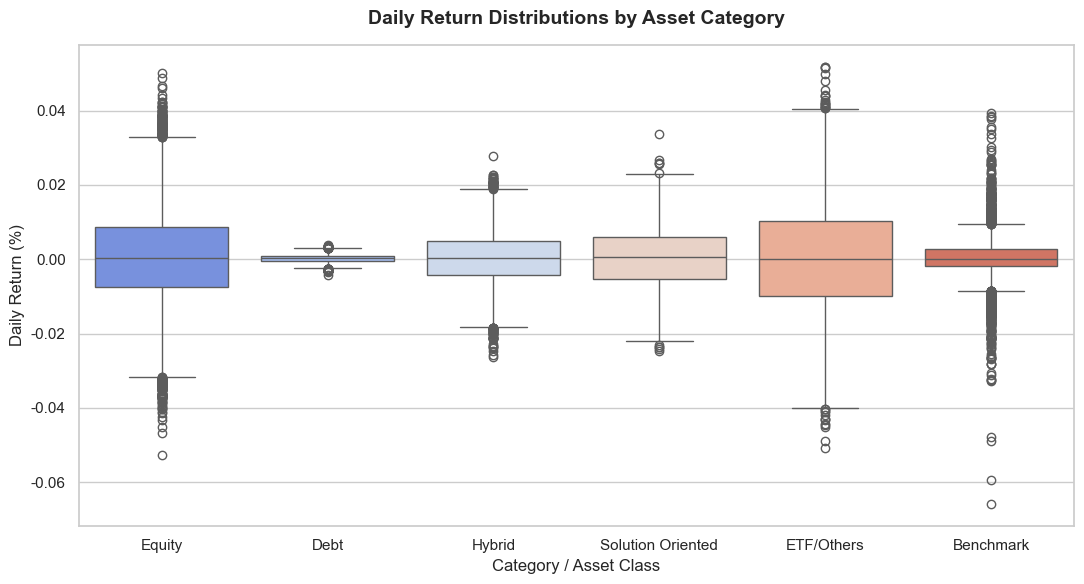

In [5]:
# Summary stats of returns
cols_to_stats = list(df_returns.columns[:5]) + ['Nifty_50', 'Nifty_100']
print("Summary Statistics for Daily Returns (Sample):")
print(df_returns[cols_to_stats].describe())

# Map columns to categories for visual distribution validation
cat_map = df_funds.set_index('amfi_code')['category'].to_dict()
plot_data = []
for col in df_returns.columns:
    cat = cat_map.get(col, 'Benchmark')
    for val in df_returns[col]:
        plot_data.append({'Category': cat, 'Daily Return': val})
df_plot = pd.DataFrame(plot_data)

# Boxplot of distributions
plt.figure(figsize=(11, 6))
sns.boxplot(data=df_plot, x='Category', y='Daily Return', palette='coolwarm')
plt.title('Daily Return Distributions by Asset Category', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Daily Return (%)', fontsize=12)
plt.xlabel('Category / Asset Class', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
end_date = '2026-06-15'
start_1y = '2025-06-15'
start_3y = '2023-06-15'
start_max = '2022-01-01'

nav_end = df_merged.loc[end_date]
nav_1y = df_merged.loc[start_1y]
nav_3y = df_merged.loc[start_3y]
nav_max = df_merged.loc[start_max]

# 1-Year and 3-Year CAGR
cagr_1y = (nav_end / nav_1y) - 1.0
cagr_3y = (nav_end / nav_3y) ** (1.0 / 3.0) - 1.0

# Max Available Period CAGR (4.45 Years)
d_end = datetime.datetime.strptime(end_date, '%Y-%m-%d')
d_max = datetime.datetime.strptime(start_max, '%Y-%m-%d')
n_max = (d_end - d_max).days / 365.25
cagr_max = (nav_end / nav_max) ** (1.0 / n_max) - 1.0

# Build comparison table
cagr_table = pd.DataFrame({
    'AMFI Code': df_funds['amfi_code'],
    'Fund Name': df_funds['fund_name'],
    'Category': df_funds['category'],
    'Sub-Category': df_funds['sub_category'],
    '1Yr CAGR (%)': df_funds['amfi_code'].map(cagr_1y) * 100,
    '3Yr CAGR (%)': df_funds['amfi_code'].map(cagr_3y) * 100,
    '5Yr CAGR (4.45y Max) (%)': df_funds['amfi_code'].map(cagr_max) * 100
})
print("CAGR Comparison Table for All Funds:")
print(cagr_table.sort_values('3Yr CAGR (%)', ascending=False))

CAGR Comparison Table for All Funds:
    AMFI Code                                          Fund Name           Category        Sub-Category  1Yr CAGR (%)  3Yr CAGR (%)  5Yr CAGR (4.45y Max) (%)
1      100002         HDFC Mid Cap Fund - Direct Growth (100002)             Equity             Mid Cap       56.9878       73.0070                   54.7623
4      100005  Kotak Mahindra Large Cap Fund - Regular Growth...             Equity           Large Cap       30.5244       32.2676                   31.6832
9      100010         HDFC Mid Cap Fund - Direct Growth (100010)             Equity             Mid Cap       18.4663       30.1357                   18.7131
17     100018         HDFC Mid Cap Fund - Direct Growth (100018)             Equity             Mid Cap       19.8818       29.1044                   22.3716
34     100035  ICICI Prudential Balanced Advantage Fund - Reg...             Hybrid  Balanced Advantage       21.6316       28.4040                   23.5752
12     100013  

In [7]:
rf = 0.065
sharpe_ratios = {}
sortino_ratios = {}
volatilities = {}
downside_volatilities = {}

for col in df_returns.columns:
    # Volatility
    daily_std = df_returns[col].std()
    ann_vol = daily_std * np.sqrt(252)
    volatilities[col] = ann_vol
    
    # Sharpe using Compounded CAGR over max period as annualized return (Rp)
    ann_ret = cagr_max[col]
    sharpe_ratios[col] = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan
    
    # Downside Volatility
    downside_std = np.sqrt(np.mean(np.minimum(df_returns[col], 0.0)**2))
    ann_downside_vol = downside_std * np.sqrt(252)
    downside_volatilities[col] = ann_downside_vol
    
    # Sortino Ratio
    sortino_ratios[col] = (ann_ret - rf) / ann_downside_vol if ann_downside_vol > 0 else np.nan

df_ratios = pd.DataFrame({
    'AMFI Code': df_funds['amfi_code'],
    'Fund Name': df_funds['fund_name'],
    'Annualized Volatility (%)': df_funds['amfi_code'].map(volatilities) * 100,
    'Annualized Downside Vol (%)': df_funds['amfi_code'].map(downside_volatilities) * 100,
    'Sharpe Ratio': df_funds['amfi_code'].map(sharpe_ratios),
    'Sortino Ratio': df_funds['amfi_code'].map(sortino_ratios)
})
print("Ratios and Risk Statistics Table:")
print(df_ratios.sort_values('Sharpe Ratio', ascending=False))

Ratios and Risk Statistics Table:
    AMFI Code                                          Fund Name  Annualized Volatility (%)  Annualized Downside Vol (%)  Sharpe Ratio  Sortino Ratio
1      100002         HDFC Mid Cap Fund - Direct Growth (100002)                    19.3094                      12.5087        2.4994         3.8583
21     100022            Axis Gilt Fund - Direct Growth (100022)                     1.5865                       0.9054        1.5596         2.7330
34     100035  ICICI Prudential Balanced Advantage Fund - Reg...                    11.1068                       7.3535        1.5374         2.3220
2      100003  ICICI Prudential Small Cap Fund - Regular Grow...                    18.9576                      12.5729        1.3880         2.0929
24     100025            SBI Gilt Fund - Regular Growth (100025)                     1.5904                       0.9422        1.3691         2.3110
4      100005  Kotak Mahindra Large Cap Fund - Regular Growth...  

In [8]:
# Run OLS on active trading days only
trading_days = df_returns.index[df_returns['Nifty_100'] != 0]

alpha_dict = {}
beta_dict = {}

for code in df_funds['amfi_code']:
    fund_ret_trading = df_returns.loc[trading_days, code]
    nifty_ret_trading = df_returns.loc[trading_days, 'Nifty_100']
    
    slope, intercept, r_value, p_value, std_err = linregress(nifty_ret_trading, fund_ret_trading)
    beta_dict[code] = slope
    alpha_dict[code] = intercept * 252.0 # Annualized Alpha

df_alpha_beta = pd.DataFrame({
    'AMFI Code': df_funds['amfi_code'],
    'Fund Name': df_funds['fund_name'],
    'Category': df_funds['category'],
    'Alpha (Annualized, %)': df_funds['amfi_code'].map(alpha_dict) * 100,
    'Beta': df_funds['amfi_code'].map(beta_dict)
})
print("Alpha and Beta Coefficients:")
print(df_alpha_beta.sort_values('Alpha (Annualized, %)', ascending=False))

Alpha and Beta Coefficients:
    AMFI Code                                          Fund Name           Category  Alpha (Annualized, %)    Beta
1      100002         HDFC Mid Cap Fund - Direct Growth (100002)             Equity                44.0296 -0.0209
2      100003  ICICI Prudential Small Cap Fund - Regular Grow...             Equity                26.5448 -0.0074
5      100006         Axis Mid Cap Fund - Direct Growth (100006)             Equity                23.8876  0.0153
16     100017       SBI Large Cap Fund - Regular Growth (100017)             Equity                22.7263 -0.0031
4      100005  Kotak Mahindra Large Cap Fund - Regular Growth...             Equity                21.0966  0.0033
34     100035  ICICI Prudential Balanced Advantage Fund - Reg...             Hybrid                20.7033  0.0131
12     100013  Kotak Mahindra Large Cap Fund - Regular Growth...             Equity                19.6815  0.0504
8      100009       SBI Large Cap Fund - Regular Gr

In [9]:
max_dd_dict = {}
worst_dd_start_dict = {}
worst_dd_trough_dict = {}
worst_dd_recovery_dict = {}

for col in df_merged.columns:
    nav_series = df_merged[col]
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1.0
    
    max_dd_dict[col] = drawdown.min()
    trough_date = drawdown.idxmin()
    
    pre_trough_navs = nav_series.loc[:trough_date]
    peak_date = pre_trough_navs.idxmax()
    peak_val = nav_series.loc[peak_date]
    
    post_trough_navs = nav_series.loc[trough_date:]
    recovery_navs = post_trough_navs[post_trough_navs >= peak_val]
    worst_dd_recovery_dict[col] = recovery_navs.index[0] if len(recovery_navs) > 0 else 'Unrecovered'
    worst_dd_start_dict[col] = peak_date
    worst_dd_trough_dict[col] = trough_date

df_drawdowns = pd.DataFrame({
    'AMFI Code': df_funds['amfi_code'],
    'Fund Name': df_funds['fund_name'],
    'Maximum Drawdown (%)': df_funds['amfi_code'].map(max_dd_dict) * 100,
    'Drawdown Peak Date': df_funds['amfi_code'].map(worst_dd_start_dict),
    'Drawdown Trough Date': df_funds['amfi_code'].map(worst_dd_trough_dict),
    'Recovery Date': df_funds['amfi_code'].map(worst_dd_recovery_dict)
})
print("Drawdowns and Recovery Analysis:")
print(df_drawdowns.sort_values('Maximum Drawdown (%)'))

Drawdowns and Recovery Analysis:
    AMFI Code                                          Fund Name  Maximum Drawdown (%) Drawdown Peak Date Drawdown Trough Date Recovery Date
38     100039    UTI Nifty 50 ETF Fund - Regular Growth (100039)              -56.3080         2023-11-25           2026-06-07   Unrecovered
7      100008  Aditya Birla Sun Life Flexi Cap Fund - Direct ...              -43.9479         2024-05-25           2026-03-08   Unrecovered
15     100016  Aditya Birla Sun Life Flexi Cap Fund - Direct ...              -42.3126         2022-03-08           2023-03-19    2025-03-08
13     100014         Axis Mid Cap Fund - Direct Growth (100014)              -40.2400         2022-07-27           2024-09-19   Unrecovered
39     100040  Aditya Birla Sun Life Gold ETF Fund - Direct G...              -37.0875         2022-02-04           2022-06-29    2023-03-12
6      100007       UTI Small Cap Fund - Regular Growth (100007)              -33.7526         2025-02-08           2026-

In [10]:
expense_ratio_map = df_perf_static.set_index('amfi_code')['expense_ratio'].to_dict()
scorecard_rows = []

for idx, row in df_funds.iterrows():
    code = row['amfi_code']
    scorecard_rows.append({
        'amfi_code': code,
        'fund_name': row['fund_name'],
        'category': row['category'],
        'sub_category': row['sub_category'],
        'expense_ratio': expense_ratio_map.get(code, 0.0),
        'cagr_1y': cagr_1y[code],
        'cagr_3y': cagr_3y[code],
        'cagr_5y_max': cagr_max[code],
        'volatility': volatilities[code],
        'sharpe': sharpe_ratios[code],
        'sortino': sortino_ratios[code],
        'alpha': alpha_dict[code],
        'beta': beta_dict[code],
        'max_dd': max_dd_dict[code],
        'max_dd_start': worst_dd_start_dict[code],
        'max_dd_trough': worst_dd_trough_dict[code],
        'max_dd_recovery': worst_dd_recovery_dict[code]
    })

df_scorecard = pd.DataFrame(scorecard_rows)

# Ranks
df_scorecard['rank_3y_ret'] = df_scorecard['cagr_3y'].rank(pct=True) * 100
df_scorecard['rank_sharpe'] = df_scorecard['sharpe'].rank(pct=True) * 100
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(pct=True) * 100
df_scorecard['rank_expense'] = df_scorecard['expense_ratio'].rank(pct=True, ascending=False) * 100
df_scorecard['rank_max_dd'] = df_scorecard['max_dd'].rank(pct=True) * 100

# Weighted Composite Score
df_scorecard['composite_score'] = (
    0.30 * df_scorecard['rank_3y_ret'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_max_dd']
)
df_scorecard['final_rank'] = df_scorecard['composite_score'].rank(ascending=False, method='min').astype(int)
df_scorecard = df_scorecard.sort_values('final_rank').reset_index(drop=True)

print("Fund Scorecard Ranks (Sorted by Rank):")
print(df_scorecard[['final_rank', 'fund_name', 'category', 'cagr_3y', 'sharpe', 'alpha', 'expense_ratio', 'max_dd', 'composite_score']])

Fund Scorecard Ranks (Sorted by Rank):
    final_rank                                          fund_name           category  cagr_3y  sharpe   alpha  expense_ratio  max_dd  composite_score
0            1         HDFC Mid Cap Fund - Direct Growth (100002)             Equity   0.7301  2.4994  0.4403         1.3300 -0.1958          87.0000
1            2  ICICI Prudential Small Cap Fund - Regular Grow...             Equity   0.2241  1.3880  0.2654         0.7900 -0.2563          80.6250
2            3  Kotak Mahindra Large Cap Fund - Regular Growth...             Equity   0.3227  1.3496  0.2110         1.2100 -0.2655          79.7500
3            4       SBI Large Cap Fund - Regular Growth (100017)             Equity   0.2341  1.1146  0.2273         0.8500 -0.2210          78.8750
4            5  ICICI Prudential Balanced Advantage Fund - Reg...             Hybrid   0.2840  1.5374  0.2070         1.4700 -0.1199          78.7500
5            6  ICICI Prudential Small Cap Fund - Regular Gro

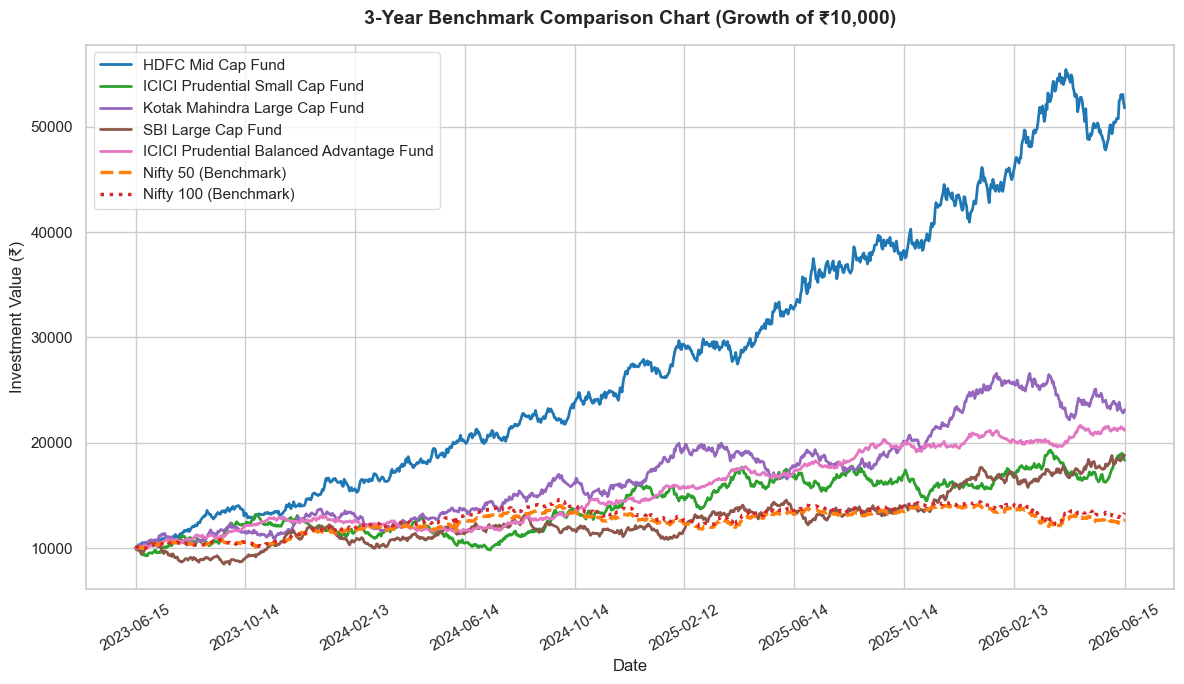

Tracking Errors for Top 5 Funds:
                                  Fund Name  Tracking Error vs Nifty 50 (%)  Tracking Error vs Nifty 100 (%)
0                         HDFC Mid Cap Fund                         22.2204                          22.4859
1           ICICI Prudential Small Cap Fund                         21.9356                          22.1561
2             Kotak Mahindra Large Cap Fund                         21.4446                          21.6418
3                        SBI Large Cap Fund                         21.9623                          22.2207
4  ICICI Prudential Balanced Advantage Fund                         15.0809                          15.3252


In [11]:
top_5 = df_scorecard.head(5)
top_5_codes = top_5['amfi_code'].tolist()

date_mask = (df_merged.index >= start_3y) & (df_merged.index <= end_date)
df_3y_prices = df_merged.loc[date_mask].copy()

# Cumulative returns growth of 10,000 INR
df_cumulative = pd.DataFrame(index=df_3y_prices.index)
initial_val = 10000.0
for code in top_5_codes:
    name = top_5[top_5['amfi_code'] == code]['fund_name'].values[0].split(' - ')[0]
    df_cumulative[name] = initial_val * (df_3y_prices[code] / df_3y_prices[code].iloc[0])
df_cumulative['Nifty 50'] = initial_val * (df_3y_prices['Nifty_50'] / df_3y_prices['Nifty_50'].iloc[0])
df_cumulative['Nifty 100'] = initial_val * (df_3y_prices['Nifty_100'] / df_3y_prices['Nifty_100'].iloc[0])

# Plotting Comparison Chart
plt.figure(figsize=(12, 7))
colors = ['#1F77B4', '#2CA02C', '#9467BD', '#8C564B', '#E377C2']
for idx, col in enumerate(df_cumulative.columns[:-2]):
    plt.plot(df_cumulative.index, df_cumulative[col], label=col, color=colors[idx], linewidth=2)
plt.plot(df_cumulative.index, df_cumulative['Nifty 50'], label='Nifty 50 (Benchmark)', color='#FF7F0E', linewidth=2.5, linestyle='--')
plt.plot(df_cumulative.index, df_cumulative['Nifty 100'], label='Nifty 100 (Benchmark)', color='#D62728', linewidth=2.5, linestyle=':')

plt.title('3-Year Benchmark Comparison Chart (Growth of ₹10,000)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Investment Value (₹)', fontsize=12)

all_dates = list(df_cumulative.index)
tick_indices = np.linspace(0, len(all_dates)-1, 10, dtype=int)
plt.xticks(tick_indices, [all_dates[i] for i in tick_indices], rotation=30)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='lightgray')
plt.tight_layout()
plt.show()

# Compute Tracking Errors over 3 years
df_returns_3y = df_returns.loc[df_returns.index >= start_3y]
te_rows = []
for code in top_5_codes:
    name = top_5[top_5['amfi_code'] == code]['fund_name'].values[0].split(' - ')[0]
    te_50 = (df_returns_3y[code] - df_returns_3y['Nifty_50']).std() * np.sqrt(252)
    te_100 = (df_returns_3y[code] - df_returns_3y['Nifty_100']).std() * np.sqrt(252)
    te_rows.append({
        'Fund Name': name,
        'Tracking Error vs Nifty 50 (%)': te_50 * 100,
        'Tracking Error vs Nifty 100 (%)': te_100 * 100
    })
df_te = pd.DataFrame(te_rows)
print("Tracking Errors for Top 5 Funds:")
print(df_te)